> [返回仓库首页](../README.md) · [查看可视化学习路线](../docs/learning-roadmap.md)

建议按路线图顺序学习本章。

# 信用卡客户违约风险预测：五种 sklearn 模型比较

**项目定位**：假设这是一次课程数据建模竞赛。参赛者需要根据客户过去六个月的信用额度、账单和还款记录，
预测客户下个月是否违约，并提交一份可复现的模型比较报告。

**本 Notebook 的提交内容**：数据检查、统一预处理、五模型训练、交叉验证、独立测试集评估、
可视化比较，以及基于误判成本的风险阈值分析。

> 所有正式模型均直接调用 `scikit-learn`。数据是教学与研究用历史样本，结果不能直接用于真实授信。

## 0. 项目说明与建模任务

### 0.1 竞赛任务：预测下月是否违约

每行数据代表一位信用卡客户。输入包括信用额度、客户属性、最近六个月还款状态、账单金额和实际还款金额；
需要预测的标签为：

$$
y =
\begin{cases}
1, & \text{客户下个月违约},\\
0, & \text{客户下个月未违约}.
\end{cases}
$$

### 0.2 评价思路：不能只追求 Accuracy

违约客户是少数类。如果只预测“不会违约”，Accuracy 仍可能看起来不错。
因此项目同时比较 Accuracy、Precision、Recall、F1、ROC-AUC 和 PR-AUC，并使用五折交叉验证选模型。

### 0.3 项目流程

```text
读取数据 → 检查质量 → 划分训练集/测试集 → Pipeline 预处理
        → 五模型交叉验证 → sklearn fit / predict
        → metrics 与图形比较 → 概率校准 → 风险阈值
```

### 0.4 数据与参考资料

- [UCI：Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default)
  （Yeh, 2009，DOI: [10.24432/C55S3H](https://doi.org/10.24432/C55S3H)）；
- [scikit-learn：Pipeline](https://scikit-learn.org/stable/modules/compose.html)；
- [scikit-learn：模型评估](https://scikit-learn.org/stable/modules/model_evaluation.html)；
- [scikit-learn：概率校准](https://scikit-learn.org/stable/modules/calibration.html)。

数据包含 30,000 位台湾地区信用卡客户的历史记录，来自 2005 年。数据集使用 CC BY 4.0 许可。

### 0.5 完整目录

- [1. 数据读取与初步认识](#data)
- [2. 数据检查与特征准备](#prepare)
- [3. sklearn 五种模型建模](#models)
- [4. 交叉验证与模型选择](#cv)
- [5. sklearn 测试集评估与可视化](#test)
- [6. 金融业务预测与实际应用](#business)
- [7. 结果总结与运行验证](#summary)

<a id="data"></a>
## 1. 数据读取与初步认识

### 1.1 导入通用依赖

In [1]:
from pathlib import Path
import json
import os
import time
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

### 1.2 设置随机种子与绘图风格

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
N_JOBS = 1
BLUE = "#2F6BFF"
ORANGE = "#F29E4C"
GOLD = "#D9A441"
DARK = "#263238"
GREY = "#8A94A6"
LIGHT_BLUE = "#DDE7FF"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#C7CDD6",
    "grid.alpha": 0.22,
})

### 1.3 读取本地数据

将 Notebook 与 `data` 文件夹一起复制给其他人即可运行。代码只读取相对位置，不输出任何本机路径。

In [3]:
data_candidates = [
    Path("data/default_of_credit_card_clients.csv"),
    Path("outputs/data/default_of_credit_card_clients.csv"),
    Path.cwd() / "data" / "default_of_credit_card_clients.csv",
]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "未找到 default_of_credit_card_clients.csv；请保留 Notebook 同级 data 目录。"
    )

raw_data = pd.read_csv(DATA_PATH)
raw_data.shape

(30000, 25)

### 1.4 数据预览与字段分组

为避免一次显示 25 列造成阅读负担，先展示最能说明业务含义的字段；正式建模仍使用全部有效特征。

In [4]:
preview_columns = [
    "ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "BILL_AMT1", "PAY_AMT1", "default_payment_next_month",
]
display(raw_data[preview_columns].head())

feature_groups = pd.DataFrame({
    "Feature group": [
        "Customer profile", "Credit limit", "Repayment status",
        "Bill amount", "Payment amount", "Target",
    ],
    "Columns": [
        "SEX, EDUCATION, MARRIAGE, AGE",
        "LIMIT_BAL",
        "PAY_0, PAY_2, ..., PAY_6",
        "BILL_AMT1, ..., BILL_AMT6",
        "PAY_AMT1, ..., PAY_AMT6",
        "default_payment_next_month",
    ],
    "Meaning": [
        "Basic customer attributes",
        "Granted credit limit",
        "Recent repayment/delay status",
        "Monthly statement balances",
        "Actual monthly repayments",
        "1 = default next month",
    ],
})
display(feature_groups)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,BILL_AMT1,PAY_AMT1,default_payment_next_month
0,1,20000,2,2,1,24,2,3913,0,1
1,2,120000,2,2,2,26,-1,2682,0,1
2,3,90000,2,2,2,34,0,29239,1518,0
3,4,50000,2,2,1,37,0,46990,2000,0
4,5,50000,1,2,1,57,-1,8617,2000,0


,Feature group,Columns,Meaning
0,Customer profile,"SEX, EDUCATION, MARRIAGE, AGE",Basic customer attributes
1,Credit limit,LIMIT_BAL,Granted credit limit
2,Repayment status,"PAY_0, PAY_2, ..., PAY_6",Recent repayment/delay status
3,Bill amount,"BILL_AMT1, ..., BILL_AMT6",Monthly statement balances
4,Payment amount,"PAY_AMT1, ..., PAY_AMT6",Actual monthly repayments
5,Target,default_payment_next_month,1 = default next month


### 1.5 标签分布：为什么不能只看 Accuracy

违约客户约占两成。若模型总是预测“未违约”，Accuracy 仍可能较高，却完全不能发现风险客户。
因此后面同时比较 Recall、Precision、F1、ROC-AUC 和 PR-AUC。

,Class,Count,Share
0,No default (0),23364,77.9%
1,Default (1),6636,22.1%


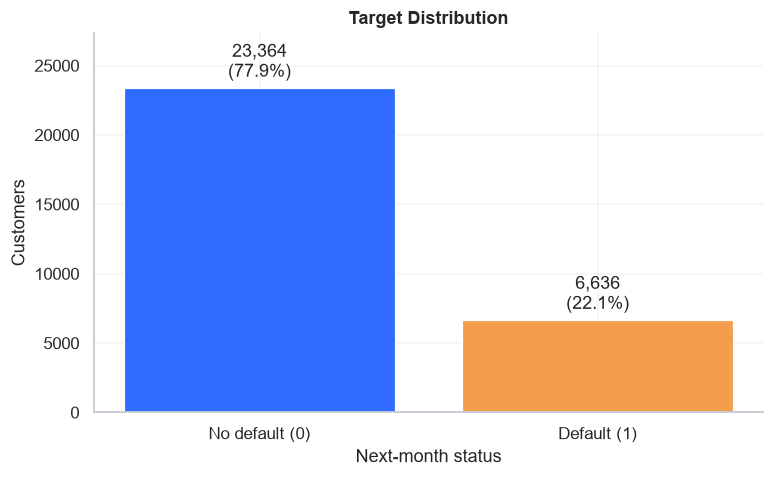

In [5]:
target_name = "default_payment_next_month"
target_counts = raw_data[target_name].value_counts().sort_index()
target_rates = raw_data[target_name].value_counts(normalize=True).sort_index()
target_summary = pd.DataFrame({
    "Class": ["No default (0)", "Default (1)"],
    "Count": target_counts.values,
    "Share": target_rates.values,
})
display(target_summary.style.format({"Share": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(7.2, 4.5))
bars = ax.bar(
    target_summary["Class"], target_summary["Count"],
    color=[BLUE, ORANGE], edgecolor="white", linewidth=0.8,
)
ax.bar_label(
    bars,
    labels=[
        f"{count:,}\n({share:.1%})"
        for count, share in zip(target_summary["Count"], target_summary["Share"])
    ],
    padding=4,
)
ax.set(
    title="Target Distribution",
    xlabel="Next-month status",
    ylabel="Customers",
)
ax.set_ylim(0, target_summary["Count"].max() * 1.17)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

<a id="prepare"></a>
## 2. 数据检查与特征准备

### 2.1 数据质量检查与类别编码修正

`EDUCATION` 中的 0、5、6 和 `MARRIAGE` 中的 0 属于未明确类别。这里统一归入 `Other`，
并将三个人口属性转换为可读类别标签。`ID` 只用于最后展示客户，不进入模型。

In [6]:
quality_summary = pd.DataFrame({
    "Check": ["Rows", "Columns", "Missing cells", "Duplicate rows", "Target classes"],
    "Observed": [
        len(raw_data),
        raw_data.shape[1],
        int(raw_data.isna().sum().sum()),
        int(raw_data.duplicated().sum()),
        sorted(raw_data[target_name].unique().tolist()),
    ],
    "Status": ["Pass", "Pass", "Pass", "Pass", "Pass"],
})
display(quality_summary)

data = raw_data.copy()
data["SEX"] = data["SEX"].map({1: "Male", 2: "Female"}).fillna("Other")
data["EDUCATION"] = data["EDUCATION"].replace({0: 4, 5: 4, 6: 4}).map({
    1: "Graduate school", 2: "University", 3: "High school", 4: "Other"
})
data["MARRIAGE"] = data["MARRIAGE"].replace({0: 3}).map({
    1: "Married", 2: "Single", 3: "Other"
})

assert data.shape == (30000, 25)
assert data.isna().sum().sum() == 0
assert set(data[target_name]) == {0, 1}

,Check,Observed,Status
0,Rows,30000,Pass
1,Columns,25,Pass
2,Missing cells,0,Pass
3,Duplicate rows,0,Pass
4,Target classes,"[0, 1]",Pass


### 2.2 关键变量与违约的关系

下面只做三项紧凑的描述性观察。它们显示相关关系，不表示因果关系，也不能替代正式模型评估。

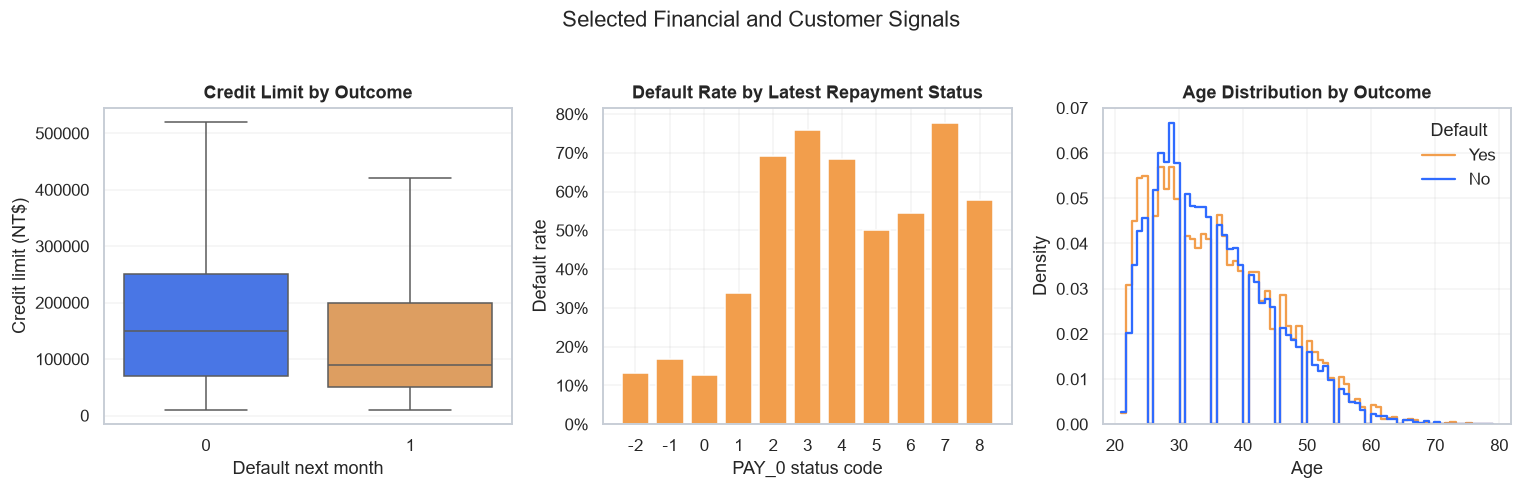

In [7]:
repayment_default_rate = (
    data.groupby("PAY_0", as_index=False)[target_name]
    .mean()
    .sort_values("PAY_0")
)

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.3))
sns.boxplot(
    data=data, x=target_name, y="LIMIT_BAL", hue=target_name,
    palette=[BLUE, ORANGE], showfliers=False, legend=False, ax=axes[0],
)
axes[0].set(
    title="Credit Limit by Outcome",
    xlabel="Default next month",
    ylabel="Credit limit (NT$)",
)

axes[1].bar(
    repayment_default_rate["PAY_0"].astype(str),
    repayment_default_rate[target_name],
    color=ORANGE, edgecolor="white",
)
axes[1].set(
    title="Default Rate by Latest Repayment Status",
    xlabel="PAY_0 status code",
    ylabel="Default rate",
)
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

sns.histplot(
    data=data, x="AGE", hue=target_name, stat="density",
    common_norm=False, element="step", fill=False,
    palette=[BLUE, ORANGE], ax=axes[2],
)
axes[2].set(
    title="Age Distribution by Outcome",
    xlabel="Age",
    ylabel="Density",
)
axes[2].legend(title="Default", labels=["Yes", "No"], frameon=False)
fig.suptitle("Selected Financial and Customer Signals", y=1.03)
plt.tight_layout()
plt.show()

### 2.3 分层切分与统一预处理

正确顺序是：**先切分，再在训练数据上拟合预处理器**。如果先对全体数据标准化，测试集的信息会进入训练过程。

- 数值特征：`StandardScaler`；
- 类别特征：`OneHotEncoder`；
- 预处理器和模型一起放进 `Pipeline`，交叉验证的每一折都会独立拟合。

In [8]:
customer_ids = data["ID"].copy()
X = data.drop(columns=["ID", target_name])
y = data[target_name].astype(int)

categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_features = [column for column in X.columns if column not in categorical_features]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    customer_ids,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

split_summary = pd.DataFrame({
    "Partition": ["Train", "Test"],
    "Rows": [len(X_train), len(X_test)],
    "Default rate": [y_train.mean(), y_test.mean()],
})
display(split_summary.style.format({"Default rate": "{:.2%}"}))
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

,Partition,Rows,Default rate
0,Train,24000,22.12%
1,Test,6000,22.12%


Numeric features: 20
Categorical features: 3


<a id="models"></a>
## 3. sklearn 五种模型建模

### 3.1 从 sklearn 导入五个模型

这一项目不手写分类算法，五个正式模型全部使用 sklearn 官方实现。

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

### 3.2 创建模型对象

参数保持轻量，重点是比较模型机制而不是大规模调参。`DummyClassifier` 只作为多数类基线。
SVM 在比较阶段使用 `decision_function` 计算 ROC-AUC 和 PR-AUC，最终入选模型再统一校准概率。

In [10]:
dummy_estimator = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)
logistic_estimator = LogisticRegression(
    max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE
)
decision_tree_estimator = DecisionTreeClassifier(
    max_depth=7, min_samples_leaf=40, random_state=RANDOM_STATE
)
naive_bayes_estimator = GaussianNB(var_smoothing=1e-8)
svm_estimator = SVC(
    C=1.0, kernel="rbf", probability=False,
    cache_size=1000, random_state=RANDOM_STATE
)
knn_estimator = KNeighborsClassifier(
    n_neighbors=35, weights="distance", p=2, n_jobs=N_JOBS
)

model_estimators = {
    "Dummy baseline": dummy_estimator,
    "Logistic Regression": logistic_estimator,
    "Decision Tree": decision_tree_estimator,
    "Gaussian Naive Bayes": naive_bayes_estimator,
    "SVM (RBF)": svm_estimator,
    "KNN": knn_estimator,
}
formal_model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Gaussian Naive Bayes",
    "SVM (RBF)",
    "KNN",
]

### 3.3 将预处理与模型组成 Pipeline

Pipeline 保证标准化和 One-Hot 编码只从训练数据学习，交叉验证的每一折也会独立拟合预处理器。

In [11]:
model_pipelines = {
    name: Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", estimator),
    ])
    for name, estimator in model_estimators.items()
}

### 3.4 模型特点对照

In [12]:
model_overview = pd.DataFrame({
    "Model": list(model_estimators),
    "Main idea": [
        "Always predicts the majority class",
        "Linear log-odds relationship",
        "Recursive feature splitting",
        "Class-conditional probability model",
        "Maximum-margin nonlinear boundary",
        "Neighbor voting in feature space",
    ],
    "Scale sensitive": ["No", "Yes", "No", "Usually", "Yes", "Yes"],
})
display(model_overview)

,Model,Main idea,Scale sensitive
0,Dummy baseline,Always predicts the majority class,No
1,Logistic Regression,Linear log-odds relationship,Yes
2,Decision Tree,Recursive feature splitting,No
3,Gaussian Naive Bayes,Class-conditional probability model,Usually
4,SVM (RBF),Maximum-margin nonlinear boundary,Yes
5,KNN,Neighbor voting in feature space,Yes


<a id="cv"></a>
## 4. 交叉验证与模型选择

### 4.1 训练集五折交叉验证

交叉验证只在训练集上进行。`StratifiedKFold` 保持每折的违约比例接近，
最终按 **CV ROC-AUC** 选择候选模型，同时查看 Recall、F1 和 PR-AUC。

In [13]:
scoring = {
    "Accuracy": "accuracy",
    "Precision": make_scorer(precision_score, zero_division=0),
    "Recall": make_scorer(recall_score, zero_division=0),
    "F1": make_scorer(f1_score, zero_division=0),
    "ROC-AUC": "roc_auc",
    "PR-AUC": "average_precision",
}
cv = StratifiedKFold(
    n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
)

### 4.2 定义单个模型的交叉验证函数

In [14]:
def run_cross_validation(model_name, pipeline):
    started = time.perf_counter()
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=N_JOBS,
        return_train_score=False,
    )
    numeric_row = {"Model": model_name}
    display_row = {"Model": model_name}
    for metric_name in scoring:
        values = scores[f"test_{metric_name}"]
        numeric_row[f"CV {metric_name}"] = float(values.mean())
        display_row[metric_name] = f"{values.mean():.3f} ± {values.std():.3f}"
    numeric_row["Fit Time"] = float(scores["fit_time"].mean())
    numeric_row["Wall Time"] = float(time.perf_counter() - started)
    display_row["Fit Time"] = f"{scores['fit_time'].mean():.2f}s"
    return numeric_row, display_row

### 4.3 运行六组验证并选择模型

In [15]:
cv_numeric_rows = []
cv_display_rows = []
for model_name, pipeline in model_pipelines.items():
    numeric_row, display_row = run_cross_validation(model_name, pipeline)
    cv_numeric_rows.append(numeric_row)
    cv_display_rows.append(display_row)

cv_results = pd.DataFrame(cv_numeric_rows).sort_values(
    "CV ROC-AUC", ascending=False
).reset_index(drop=True)
cv_table = pd.DataFrame(cv_display_rows).set_index("Model").loc[cv_results["Model"]].reset_index()
display(cv_table)

best_model_name = (
    cv_results[cv_results["Model"].isin(formal_model_names)]
    .sort_values("CV ROC-AUC", ascending=False)
    .iloc[0]["Model"]
)
print(f"Selected by training CV ROC-AUC: {best_model_name}")

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Fit Time
0,Decision Tree,0.818 ± 0.002,0.661 ± 0.012,0.366 ± 0.008,0.471 ± 0.006,0.764 ± 0.006,0.529 ± 0.008,0.15s
1,KNN,0.814 ± 0.003,0.656 ± 0.011,0.335 ± 0.006,0.444 ± 0.008,0.752 ± 0.007,0.513 ± 0.010,0.03s
2,Gaussian Naive Bayes,0.667 ± 0.033,0.369 ± 0.026,0.691 ± 0.014,0.480 ± 0.020,0.734 ± 0.013,0.485 ± 0.018,0.04s
3,Logistic Regression,0.811 ± 0.003,0.711 ± 0.017,0.246 ± 0.012,0.365 ± 0.014,0.727 ± 0.012,0.507 ± 0.012,0.08s
4,SVM (RBF),0.820 ± 0.002,0.685 ± 0.019,0.342 ± 0.008,0.456 ± 0.005,0.723 ± 0.006,0.511 ± 0.010,14.22s
5,Dummy baseline,0.779 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,0.221 ± 0.000,0.03s


Selected by training CV ROC-AUC: Decision Tree


### 4.4 交叉验证结果可视化

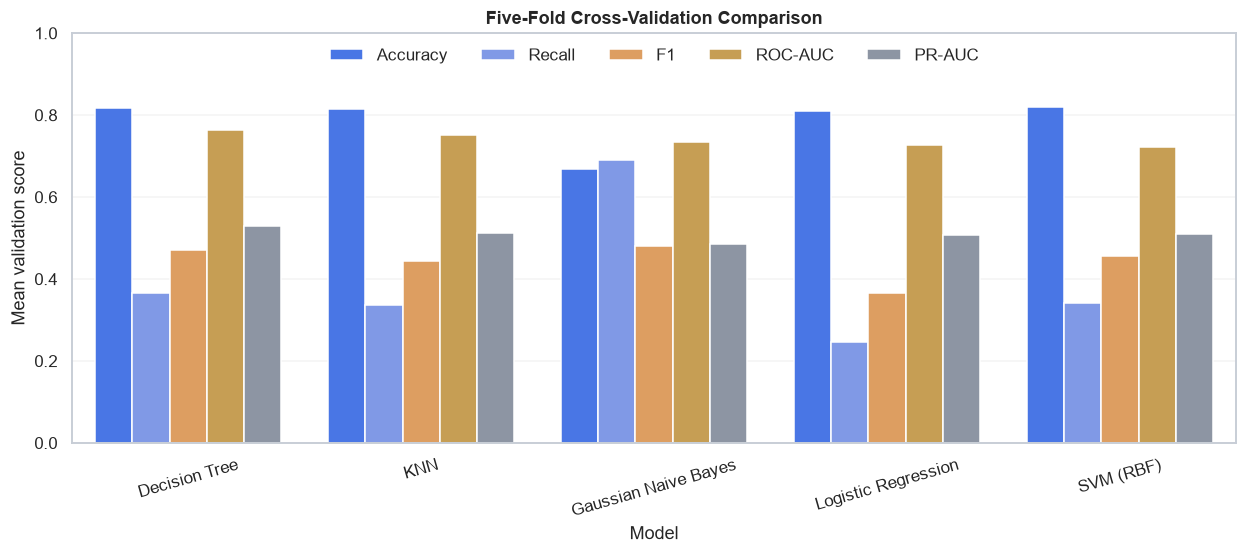

In [16]:
cv_plot_data = (
    cv_results[cv_results["Model"].isin(formal_model_names)]
    .melt(
        id_vars="Model",
        value_vars=["CV Accuracy", "CV Recall", "CV F1", "CV ROC-AUC", "CV PR-AUC"],
        var_name="Metric",
        value_name="Score",
    )
)
cv_plot_data["Metric"] = cv_plot_data["Metric"].str.replace("CV ", "", regex=False)

fig, ax = plt.subplots(figsize=(11.5, 5.2))
sns.barplot(
    data=cv_plot_data,
    x="Model",
    y="Score",
    hue="Metric",
    palette=[BLUE, "#6F91F7", ORANGE, GOLD, GREY],
    ax=ax,
)
ax.set(
    title="Five-Fold Cross-Validation Comparison",
    xlabel="Model",
    ylabel="Mean validation score",
    ylim=(0, 1),
)
ax.tick_params(axis="x", rotation=16)
ax.legend(title=None, ncol=5, frameon=False, loc="upper center")
plt.tight_layout()
plt.show()

<a id="test"></a>
## 5. sklearn 测试集评估与可视化

### 5.1 定义统一的分类评估函数

现在才使用独立测试集。五个模型使用相同的训练集、测试集和评价指标，
因而结果可以直接比较。下面先定义统一的 metrics 计算函数，再逐个展示
`clone → fit → predict → predict_proba / decision_function`。

In [17]:
def evaluate_binary(y_true, predictions, ranking_scores):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, ranking_scores),
        "PR-AUC": average_precision_score(y_true, ranking_scores),
    }


def build_test_record(name, prediction, ranking_score, fit_seconds, predict_seconds):
    return {
        "Model": name,
        **evaluate_binary(y_test, prediction, ranking_score),
        "Fit Time": fit_seconds,
        "Predict Time": predict_seconds,
    }

### 5.2 基线模型：Dummy Classifier

基线模型不学习真实规律，它回答“正式模型是否比简单多数类策略更好”。

In [18]:
started = time.perf_counter()
dummy_model = clone(model_pipelines["Dummy baseline"])
dummy_model.fit(X_train, y_train)
dummy_fit_seconds = time.perf_counter() - started

started = time.perf_counter()
dummy_prediction = dummy_model.predict(X_test)
dummy_ranking_score = dummy_model.predict_proba(X_test)[:, 1]
dummy_predict_seconds = time.perf_counter() - started

dummy_row = build_test_record(
    "Dummy baseline", dummy_prediction, dummy_ranking_score,
    dummy_fit_seconds, dummy_predict_seconds,
)

### 5.3 逻辑回归：训练与预测

In [19]:
started = time.perf_counter()
logistic_model = clone(model_pipelines["Logistic Regression"])
logistic_model.fit(X_train, y_train)
logistic_fit_seconds = time.perf_counter() - started

started = time.perf_counter()
logistic_prediction = logistic_model.predict(X_test)
logistic_ranking_score = logistic_model.predict_proba(X_test)[:, 1]
logistic_predict_seconds = time.perf_counter() - started

logistic_row = build_test_record(
    "Logistic Regression", logistic_prediction, logistic_ranking_score,
    logistic_fit_seconds, logistic_predict_seconds,
)

### 5.4 决策树：训练与预测

In [20]:
started = time.perf_counter()
decision_tree_model = clone(model_pipelines["Decision Tree"])
decision_tree_model.fit(X_train, y_train)
decision_tree_fit_seconds = time.perf_counter() - started

started = time.perf_counter()
decision_tree_prediction = decision_tree_model.predict(X_test)
decision_tree_ranking_score = decision_tree_model.predict_proba(X_test)[:, 1]
decision_tree_predict_seconds = time.perf_counter() - started

decision_tree_row = build_test_record(
    "Decision Tree", decision_tree_prediction, decision_tree_ranking_score,
    decision_tree_fit_seconds, decision_tree_predict_seconds,
)

### 5.5 朴素贝叶斯：训练与预测

In [21]:
started = time.perf_counter()
naive_bayes_model = clone(model_pipelines["Gaussian Naive Bayes"])
naive_bayes_model.fit(X_train, y_train)
naive_bayes_fit_seconds = time.perf_counter() - started

started = time.perf_counter()
naive_bayes_prediction = naive_bayes_model.predict(X_test)
naive_bayes_ranking_score = naive_bayes_model.predict_proba(X_test)[:, 1]
naive_bayes_predict_seconds = time.perf_counter() - started

naive_bayes_row = build_test_record(
    "Gaussian Naive Bayes", naive_bayes_prediction, naive_bayes_ranking_score,
    naive_bayes_fit_seconds, naive_bayes_predict_seconds,
)

### 5.6 支持向量机：训练与预测

当前 `SVC` 未开启概率估计，因此用 `decision_function` 的连续分数计算 ROC-AUC 和 PR-AUC。

In [22]:
started = time.perf_counter()
svm_model = clone(model_pipelines["SVM (RBF)"])
svm_model.fit(X_train, y_train)
svm_fit_seconds = time.perf_counter() - started

started = time.perf_counter()
svm_prediction = svm_model.predict(X_test)
svm_ranking_score = svm_model.decision_function(X_test)
svm_predict_seconds = time.perf_counter() - started

svm_row = build_test_record(
    "SVM (RBF)", svm_prediction, svm_ranking_score,
    svm_fit_seconds, svm_predict_seconds,
)

### 5.7 K近邻：训练与预测

In [23]:
started = time.perf_counter()
knn_model = clone(model_pipelines["KNN"])
knn_model.fit(X_train, y_train)
knn_fit_seconds = time.perf_counter() - started

started = time.perf_counter()
knn_prediction = knn_model.predict(X_test)
knn_ranking_score = knn_model.predict_proba(X_test)[:, 1]
knn_predict_seconds = time.perf_counter() - started

knn_row = build_test_record(
    "KNN", knn_prediction, knn_ranking_score,
    knn_fit_seconds, knn_predict_seconds,
)

### 5.8 汇总测试集 metrics

表格同时给出分类阈值指标、排序指标以及训练/预测耗时；后续图表均由这组结果生成。

In [24]:
fitted_models = {
    "Dummy baseline": dummy_model,
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Gaussian Naive Bayes": naive_bayes_model,
    "SVM (RBF)": svm_model,
    "KNN": knn_model,
}
test_predictions = {
    "Dummy baseline": dummy_prediction,
    "Logistic Regression": logistic_prediction,
    "Decision Tree": decision_tree_prediction,
    "Gaussian Naive Bayes": naive_bayes_prediction,
    "SVM (RBF)": svm_prediction,
    "KNN": knn_prediction,
}
test_ranking_scores = {
    "Dummy baseline": dummy_ranking_score,
    "Logistic Regression": logistic_ranking_score,
    "Decision Tree": decision_tree_ranking_score,
    "Gaussian Naive Bayes": naive_bayes_ranking_score,
    "SVM (RBF)": svm_ranking_score,
    "KNN": knn_ranking_score,
}
test_rows = [
    dummy_row, logistic_row, decision_tree_row,
    naive_bayes_row, svm_row, knn_row,
]
test_results = pd.DataFrame(test_rows).sort_values(
    "ROC-AUC", ascending=False
).reset_index(drop=True)
display(
    test_results.style.format({
        "Accuracy": "{:.3f}", "Precision": "{:.3f}",
        "Recall": "{:.3f}", "F1": "{:.3f}",
        "ROC-AUC": "{:.3f}", "PR-AUC": "{:.3f}",
        "Fit Time": "{:.2f}s", "Predict Time": "{:.2f}s",
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Fit Time,Predict Time
0,Decision Tree,0.815,0.655,0.348,0.455,0.752,0.509,0.18s,0.02s
1,KNN,0.811,0.636,0.338,0.442,0.745,0.510,0.03s,1.21s
2,Gaussian Naive Bayes,0.661,0.359,0.680,0.470,0.725,0.478,0.04s,0.02s
3,SVM (RBF),0.816,0.665,0.340,0.450,0.720,0.506,22.94s,9.49s
4,Logistic Regression,0.809,0.692,0.244,0.361,0.710,0.495,0.09s,0.01s
5,Dummy baseline,0.779,0.000,0.000,0.000,0.500,0.221,0.03s,0.01s


### 5.9 指标总览图

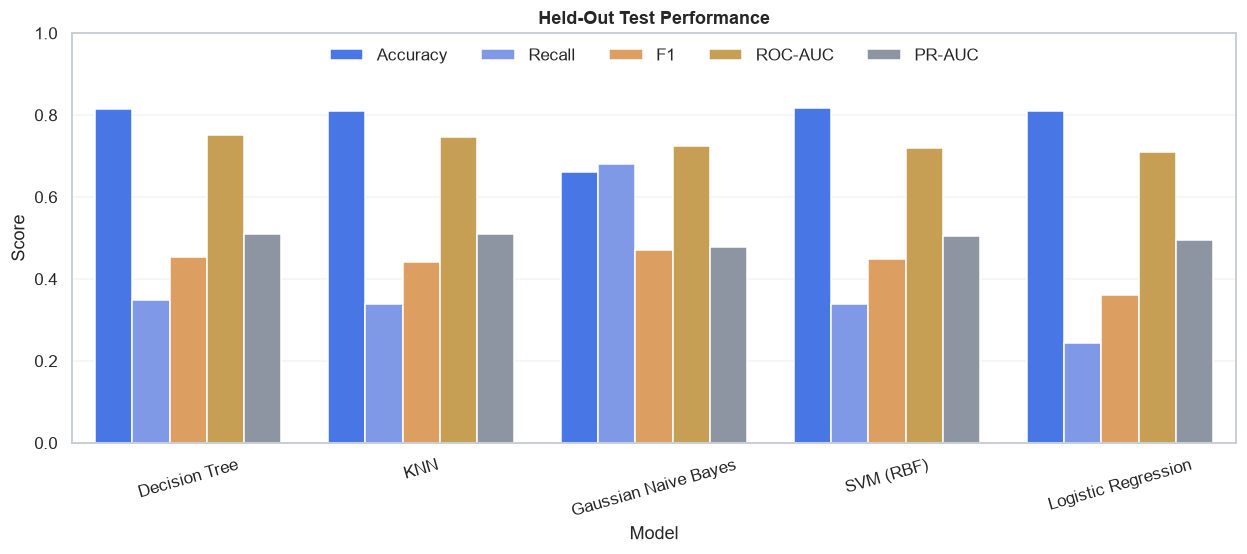

In [25]:
formal_test_results = test_results[
    test_results["Model"].isin(formal_model_names)
].copy()
metric_plot_data = formal_test_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Recall", "F1", "ROC-AUC", "PR-AUC"],
    var_name="Metric",
    value_name="Score",
)

fig, ax = plt.subplots(figsize=(11.5, 5.2))
sns.barplot(
    data=metric_plot_data,
    x="Model",
    y="Score",
    hue="Metric",
    palette=[BLUE, "#6F91F7", ORANGE, GOLD, GREY],
    ax=ax,
)
ax.set(
    title="Held-Out Test Performance",
    xlabel="Model",
    ylabel="Score",
    ylim=(0, 1),
)
ax.tick_params(axis="x", rotation=16)
ax.legend(title=None, ncol=5, frameon=False, loc="upper center")
plt.tight_layout()
plt.show()

### 5.10 混淆矩阵：分别看漏判与误报

- **FN（漏判）**：实际违约却预测为未违约，可能产生直接信用损失；
- **FP（误报）**：实际未违约却预测为违约，可能造成不必要审核或客户体验损失。

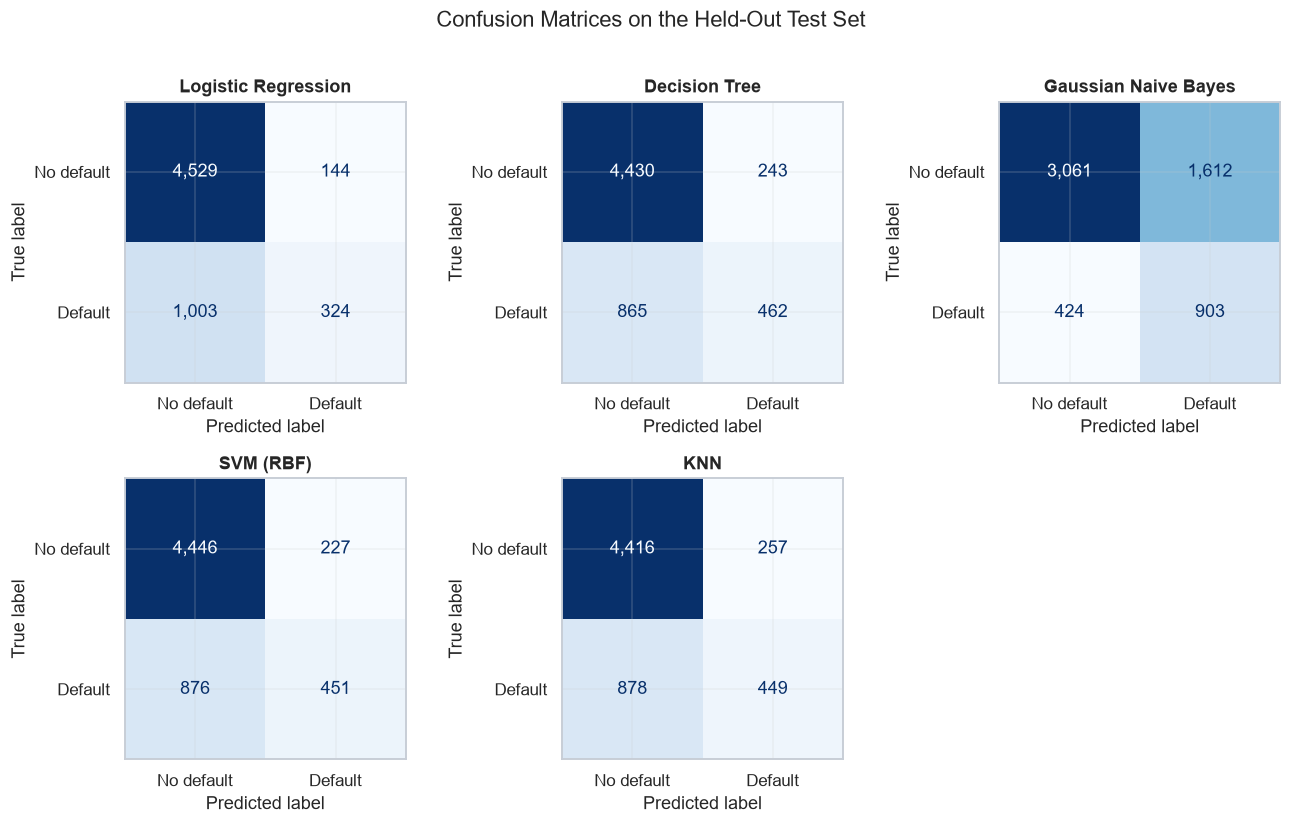

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(12.2, 7.4))
for ax, model_name in zip(axes.flat, formal_model_names):
    matrix = confusion_matrix(y_test, test_predictions[model_name])
    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["No default", "Default"],
    ).plot(ax=ax, cmap="Blues", colorbar=False, values_format=",d")
    ax.set_title(model_name)
axes.flat[-1].axis("off")
fig.suptitle("Confusion Matrices on the Held-Out Test Set", y=1.01)
plt.tight_layout()
plt.show()

### 5.11 ROC 与 Precision-Recall：观察所有阈值

ROC-AUC 衡量整体排序能力；PR 曲线更聚焦少数类“违约客户”，在类别不均衡时比 Accuracy 更有信息量。

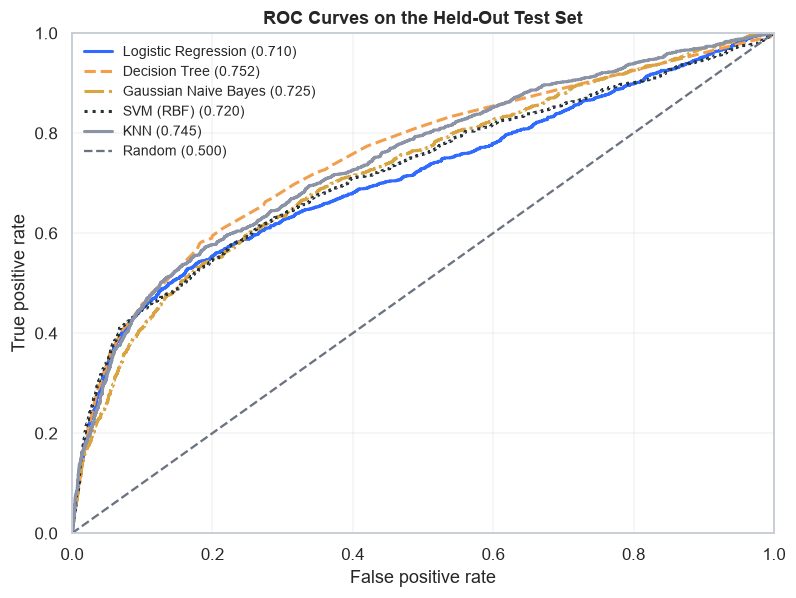

In [27]:
fig, ax = plt.subplots(figsize=(7.4, 5.6))
line_styles = ["-", "--", "-.", ":", "-"]
colors = [BLUE, ORANGE, GOLD, DARK, GREY]
for model_name, color, line_style in zip(formal_model_names, colors, line_styles):
    fpr, tpr, _ = roc_curve(y_test, test_ranking_scores[model_name])
    auc_value = roc_auc_score(y_test, test_ranking_scores[model_name])
    ax.plot(
        fpr, tpr, color=color, linestyle=line_style, linewidth=2,
        label=f"{model_name} ({auc_value:.3f})",
    )
ax.plot([0, 1], [0, 1], color="#6B7280", linestyle="--", label="Random (0.500)")
ax.set(
    title="ROC Curves on the Held-Out Test Set",
    xlabel="False positive rate",
    ylabel="True positive rate",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

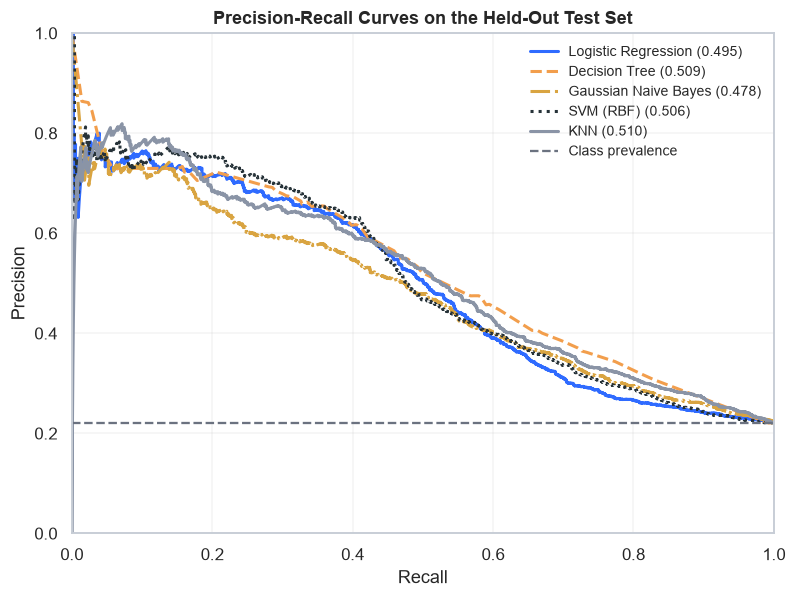

In [28]:
fig, ax = plt.subplots(figsize=(7.4, 5.6))
for model_name, color, line_style in zip(formal_model_names, colors, line_styles):
    precision_values, recall_values, _ = precision_recall_curve(
        y_test, test_ranking_scores[model_name]
    )
    ap_value = average_precision_score(y_test, test_ranking_scores[model_name])
    ax.plot(
        recall_values, precision_values,
        color=color, linestyle=line_style, linewidth=2,
        label=f"{model_name} ({ap_value:.3f})",
    )
ax.axhline(y_test.mean(), color="#6B7280", linestyle="--", label="Class prevalence")
ax.set(
    title="Precision-Recall Curves on the Held-Out Test Set",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

<a id="business"></a>
## 6. 金融业务预测与实际应用

### 6.1 用验证集选择风险阈值

`0.5` 不是天然正确的业务阈值。这里假设：漏判一位违约客户的相对成本为 5，误报一位正常客户的成本为 1。
为避免用测试集调参，我们从训练集内部再划出阈值验证集，在该验证集上选择成本最低的阈值。
阈值所使用的概率来自三折 sigmoid 校准模型。

In [29]:
X_fit, X_threshold, y_fit, y_threshold = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
def fit_risk_probability_model(model_name, features, target):
    base_pipeline = clone(model_pipelines[model_name])
    calibrated_model = CalibratedClassifierCV(
        base_pipeline,
        method="sigmoid",
        cv=3,
        n_jobs=N_JOBS,
    )
    return calibrated_model.fit(features, target)


threshold_model = fit_risk_probability_model(
    best_model_name, X_fit, y_fit
)
threshold_probabilities = threshold_model.predict_proba(X_threshold)[:, 1]

FALSE_NEGATIVE_COST = 5
FALSE_POSITIVE_COST = 1
threshold_rows = []
for threshold in np.linspace(0.05, 0.75, 71):
    predictions = (threshold_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_threshold, predictions).ravel()
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_threshold, predictions, zero_division=0),
        "Recall": recall_score(y_threshold, predictions, zero_division=0),
        "F1": f1_score(y_threshold, predictions, zero_division=0),
        "Cost per customer": (
            FALSE_NEGATIVE_COST * fn + FALSE_POSITIVE_COST * fp
        ) / len(y_threshold),
    })

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["Cost per customer", "F1"], ascending=[True, False]
).iloc[0]
business_threshold = float(best_threshold_row["Threshold"])
print(f"Selected model: {best_model_name}")
print(f"Validation-selected business threshold: {business_threshold:.2f}")

Selected model: Decision Tree
Validation-selected business threshold: 0.15


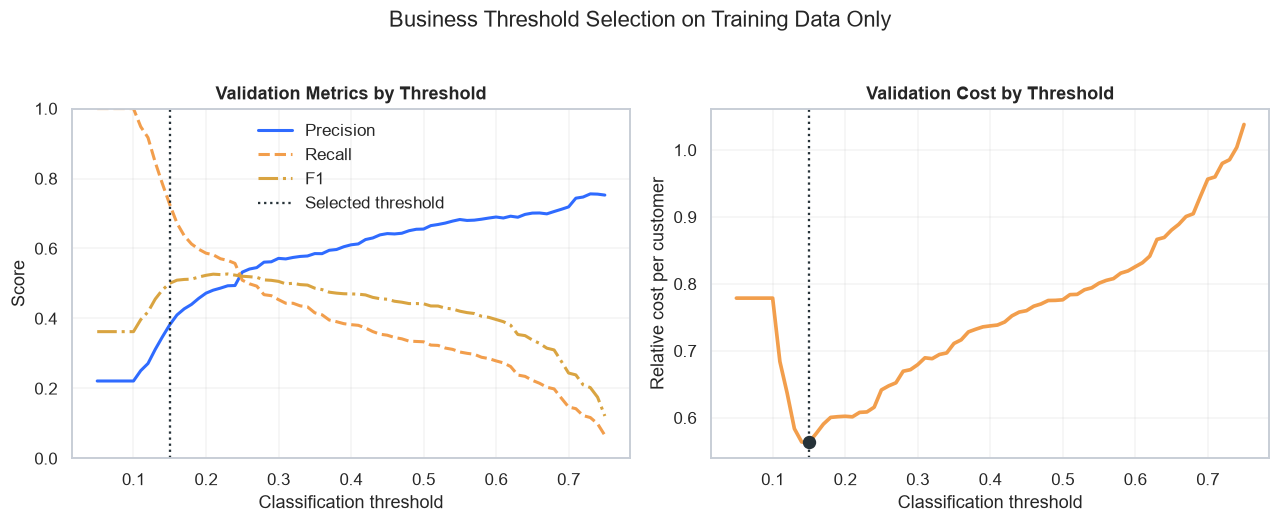

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.6))
axes[0].plot(
    threshold_results["Threshold"], threshold_results["Precision"],
    color=BLUE, linewidth=2, label="Precision",
)
axes[0].plot(
    threshold_results["Threshold"], threshold_results["Recall"],
    color=ORANGE, linewidth=2, linestyle="--", label="Recall",
)
axes[0].plot(
    threshold_results["Threshold"], threshold_results["F1"],
    color=GOLD, linewidth=2, linestyle="-.", label="F1",
)
axes[0].axvline(business_threshold, color=DARK, linestyle=":", label="Selected threshold")
axes[0].set(
    title="Validation Metrics by Threshold",
    xlabel="Classification threshold",
    ylabel="Score",
    ylim=(0, 1),
)
axes[0].legend(frameon=False)

axes[1].plot(
    threshold_results["Threshold"], threshold_results["Cost per customer"],
    color=ORANGE, linewidth=2.4,
)
axes[1].axvline(business_threshold, color=DARK, linestyle=":")
axes[1].scatter(
    [business_threshold], [best_threshold_row["Cost per customer"]],
    color=DARK, s=60, zorder=4,
)
axes[1].set(
    title="Validation Cost by Threshold",
    xlabel="Classification threshold",
    ylabel="Relative cost per customer",
)
fig.suptitle("Business Threshold Selection on Training Data Only", y=1.03)
plt.tight_layout()
plt.show()

In [31]:
risk_model = fit_risk_probability_model(
    best_model_name, X_train, y_train
)
best_test_probabilities = risk_model.predict_proba(X_test)[:, 1]

def threshold_summary(threshold):
    predictions = (best_test_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    return {
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "False positives": int(fp),
        "False negatives": int(fn),
        "Relative cost": int(FALSE_NEGATIVE_COST * fn + FALSE_POSITIVE_COST * fp),
    }

threshold_comparison = pd.DataFrame([
    {"Policy": "Default threshold", **threshold_summary(0.50)},
    {"Policy": "Business threshold", **threshold_summary(business_threshold)},
])
display(
    threshold_comparison.style.format({
        "Threshold": "{:.2f}", "Precision": "{:.3f}",
        "Recall": "{:.3f}", "F1": "{:.3f}",
    })
)

,Policy,Threshold,Precision,Recall,F1,False positives,False negatives,Relative cost
0,Default threshold,0.50,0.677,0.345,0.457,219,869,4564
1,Business threshold,0.15,0.358,0.742,0.483,1767,343,3482


### 6.2 概率校准：预测的 30% 是否真的接近 30%

排序能力好不代表概率本身准确。这里对最终入选模型应用训练集三折 sigmoid 校准，
再用测试集校准曲线比较预测概率与实际违约率；虚线表示理想校准。
Brier score 越低越好。

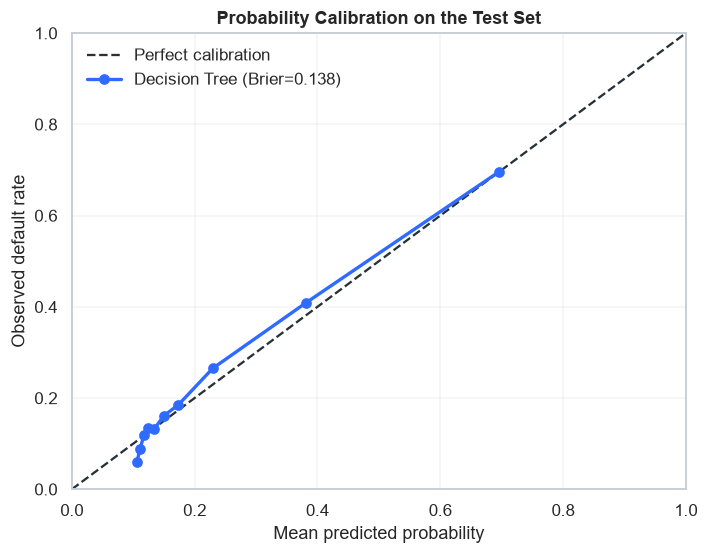

In [32]:
observed_rate, predicted_rate = calibration_curve(
    y_test,
    best_test_probabilities,
    n_bins=10,
    strategy="quantile",
)
best_brier_score = brier_score_loss(y_test, best_test_probabilities)

fig, ax = plt.subplots(figsize=(6.6, 5.2))
ax.plot([0, 1], [0, 1], "--", color=DARK, label="Perfect calibration")
ax.plot(
    predicted_rate, observed_rate,
    marker="o", linewidth=2.2, color=BLUE,
    label=f"{best_model_name} (Brier={best_brier_score:.3f})",
)
ax.set(
    title="Probability Calibration on the Test Set",
    xlabel="Mean predicted probability",
    ylabel="Observed default rate",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 6.3 置换重要性：哪些原始特征影响排序能力

对测试样本随机打乱一个原始字段，如果 ROC-AUC 明显下降，说明该字段对当前模型较重要。
这是预测贡献，不代表因果关系。

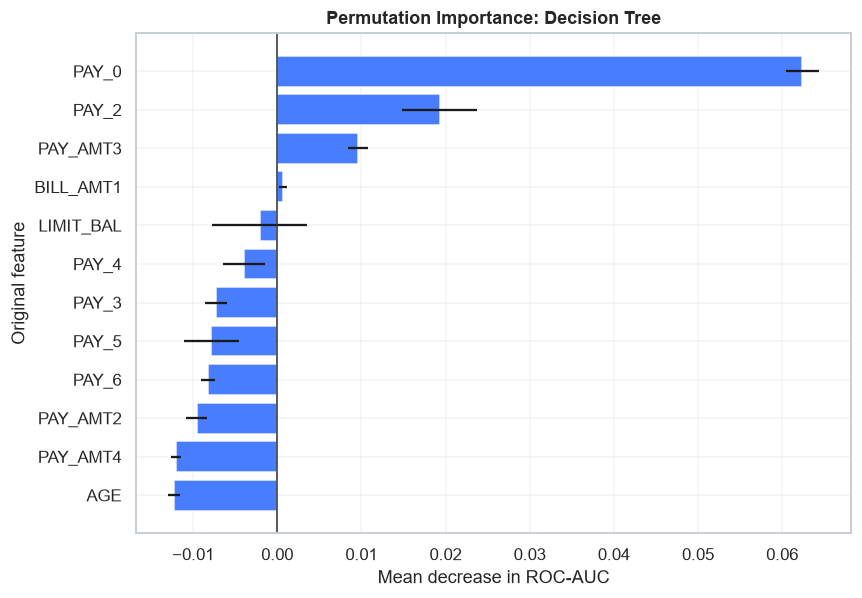

In [33]:
importance_sample_size = min(2000, len(X_test))
importance_result = permutation_importance(
    risk_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    max_samples=importance_sample_size,
)
importance_table = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": importance_result.importances_mean,
        "Std": importance_result.importances_std,
    })
    .sort_values("Importance", ascending=False)
    .head(12)
    .sort_values("Importance")
)

fig, ax = plt.subplots(figsize=(8.0, 5.6))
ax.barh(
    importance_table["Feature"], importance_table["Importance"],
    xerr=importance_table["Std"], color=BLUE,
    edgecolor="white", alpha=0.88,
)
ax.axvline(0, color=DARK, linewidth=1)
ax.set(
    title=f"Permutation Importance: {best_model_name}",
    xlabel="Mean decrease in ROC-AUC",
    ylabel="Original feature",
)
plt.tight_layout()
plt.show()

### 6.4 高风险客户清单：从模型分数到业务输出

最后把预测概率与客户 ID 重新组合。真实系统还需要权限控制、人工审核、公平性检查和持续监控；
这里仅展示离线教学结果。

In [34]:
risk_output = pd.DataFrame({
    "Customer ID": id_test.to_numpy(),
    "Actual default": y_test.to_numpy(),
    "Default probability": best_test_probabilities,
})
risk_output["Business prediction"] = (
    risk_output["Default probability"] >= business_threshold
).astype(int)
risk_output["Risk level"] = pd.cut(
    risk_output["Default probability"],
    bins=[-np.inf, business_threshold * 0.60, business_threshold, np.inf],
    labels=["Low", "Medium", "High"],
)
high_risk_customers = risk_output.sort_values(
    "Default probability", ascending=False
).head(10)
display(
    high_risk_customers.style.format({"Default probability": "{:.1%}"})
)

,Customer ID,Actual default,Default probability,Business prediction,Risk level
2695,1957,1,86.8%,1,High
5556,22760,1,86.8%,1,High
4507,12956,1,86.8%,1,High
3909,27537,1,86.8%,1,High
829,20968,1,86.6%,1,High
385,11908,1,85.5%,1,High
28,3561,1,85.5%,1,High
3980,5751,1,84.0%,1,High
4006,11267,1,83.8%,1,High
2898,17005,0,83.4%,1,High


<a id="summary"></a>
## 7. 结果总结与运行验证

### 7.1 如何阅读最终结果

- **模型选择**：依据训练集五折交叉验证 ROC-AUC，而不是测试集最高分；
- **最终性能**：测试表、混淆矩阵、ROC 与 PR 曲线来自同一独立测试集；
- **业务决策**：阈值由训练集内部验证数据和相对错误成本确定，再一次性应用到测试集；
- **解释边界**：置换重要性表示预测贡献，不能解释因果；
- **适用边界**：历史地区、年份和客户群体有限，上线前必须重新验证、校准并检查公平性。

### 7.2 计算并检查验证结果

只要前面任一核心结果缺失或出现非有限数值，下面的断言就会失败。

In [35]:
metric_columns = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
metric_values = test_results[metric_columns].to_numpy(dtype=float)
all_metrics_finite = bool(np.isfinite(metric_values).all())

validation = {
    "rows": int(len(data)),
    "raw_columns": int(data.shape[1]),
    "formal_model_count": int(len(formal_model_names)),
    "cv_folds": int(N_SPLITS),
    "all_metrics_finite": all_metrics_finite,
    "selected_model": str(best_model_name),
    "selected_threshold": round(float(business_threshold), 4),
    "test_roc_auc": round(
        float(
            test_results.loc[
                test_results["Model"] == best_model_name, "ROC-AUC"
            ].iloc[0]
        ),
        4,
    ),
    "image_count": 10,
}

assert validation["rows"] == 30000
assert validation["raw_columns"] == 25
assert validation["formal_model_count"] == 5
assert validation["all_metrics_finite"]
assert 0.0 < validation["selected_threshold"] < 1.0
assert validation["test_roc_auc"] > 0.60

### 7.3 输出运行验证表

最后一格输出可见表格和机器可读标记，方便人工检查与自动验证。

In [36]:
validation_table = pd.DataFrame({
    "Check": [
        "Data loaded",
        "Five formal models",
        "Five-fold cross-validation",
        "Finite evaluation metrics",
        "Business threshold selected",
        "Figures produced",
    ],
    "Observed": [
        f"{validation['rows']:,} rows",
        validation["formal_model_count"],
        validation["cv_folds"],
        validation["all_metrics_finite"],
        validation["selected_threshold"],
        validation["image_count"],
    ],
    "Status": ["Pass"] * 6,
})
display(validation_table)
print("CREDIT_DEFAULT_VALIDATION " + json.dumps(validation, ensure_ascii=False))

,Check,Observed,Status
0,Data loaded,"30,000 rows",Pass
1,Five formal models,5,Pass
2,Five-fold cross-validation,5,Pass
3,Finite evaluation metrics,True,Pass
4,Business threshold selected,0.15,Pass
5,Figures produced,10,Pass


CREDIT_DEFAULT_VALIDATION {"rows": 30000, "raw_columns": 25, "formal_model_count": 5, "cv_folds": 5, "all_metrics_finite": true, "selected_model": "Decision Tree", "selected_threshold": 0.15, "test_roc_auc": 0.7517, "image_count": 10}
